In [1]:
import gempy as gp
import gempy_viewer as gpv

# Aux imports
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt


np.random.seed(1515)
pd.set_option('display.precision', 2)

Setting Backend To: AvailableBackends.numpy


In [ ]:
data_path = os.path.abspath(r"C:\Users\mrcon\PycharmProjects\gempy\examples\data\input_data\tut_SandStone")

# Importing the data from csv

geo_model: gp.data.GeoModel = gp.create_geomodel(
    project_name='Greenstone',
    extent=[696000, 747000, 6863000, 6930000, -20000, 200],  # * Here we define the extent of the model
    refinement=5,  # * Here we define the number of octree levels. If octree levels are defined, the resolution is ignored.
    importer_helper=gp.data.ImporterHelper(
        path_to_orientations=data_path + "/SandStone_Foliations.csv",
        path_to_surface_points=data_path + "/SandStone_Points.csv",
        hash_surface_points=None,
        hash_orientations=None
    )
)

In [4]:
gp.map_stack_to_surfaces(
    gempy_model=geo_model,
    mapping_object={
        "EarlyGranite_Series": 'EarlyGranite',
        "BIF_Series": ('SimpleMafic2', 'SimpleBIF'),
        "SimpleMafic_Series": 'SimpleMafic1', 'Basement': 'basement'
    }
)

Could not find element 'basement' in any group.


StructuralFrame(
	structural_groups=[
StructuralGroup(
	name=EarlyGranite_Series,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=EarlyGranite,
	color=#015482,
	is_active=True
)
]
),
StructuralGroup(
	name=BIF_Series,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=SimpleMafic2,
	color=#728f02,
	is_active=True
),
Element(
	name=SimpleBIF,
	color=#9f0052,
	is_active=True
)
]
),
StructuralGroup(
	name=SimpleMafic_Series,
	structural_relation=StackRelationType.ERODE,
	elements=[
Element(
	name=SimpleMafic1,
	color=#ffbe00,
	is_active=True
)
]
)
],
	fault_relations=
[[False, False, False],
 [False, False, False],
 [False, False, False]],

c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


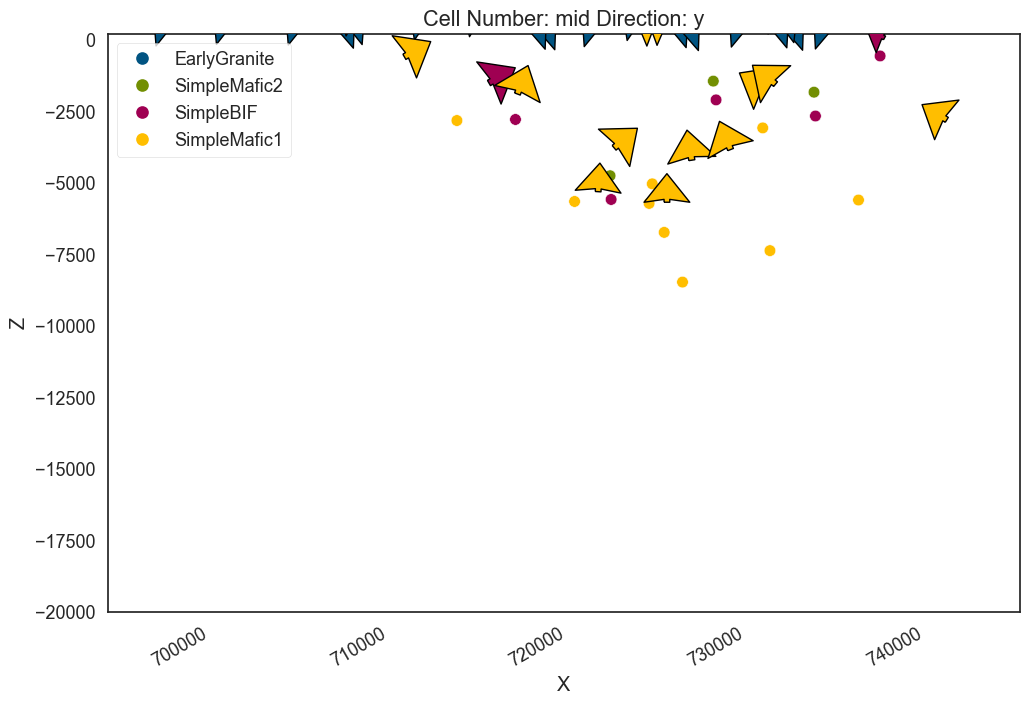

In [5]:
gpv.plot_2d(geo_model)

In [6]:
grav_res = 20
X = np.linspace(7.050000e+05, 747000, grav_res)
Y = np.linspace(6863000, 6925000, grav_res)
Z = 300
xyz = np.meshgrid(X, Y, Z)
xy_ravel = np.vstack(list(map(np.ravel, xyz))).T
xy_ravel

array([[7.05000000e+05, 6.86300000e+06, 3.00000000e+02],
       [7.07210526e+05, 6.86300000e+06, 3.00000000e+02],
       [7.09421053e+05, 6.86300000e+06, 3.00000000e+02],
       ...,
       [7.42578947e+05, 6.92500000e+06, 3.00000000e+02],
       [7.44789474e+05, 6.92500000e+06, 3.00000000e+02],
       [7.47000000e+05, 6.92500000e+06, 3.00000000e+02]])

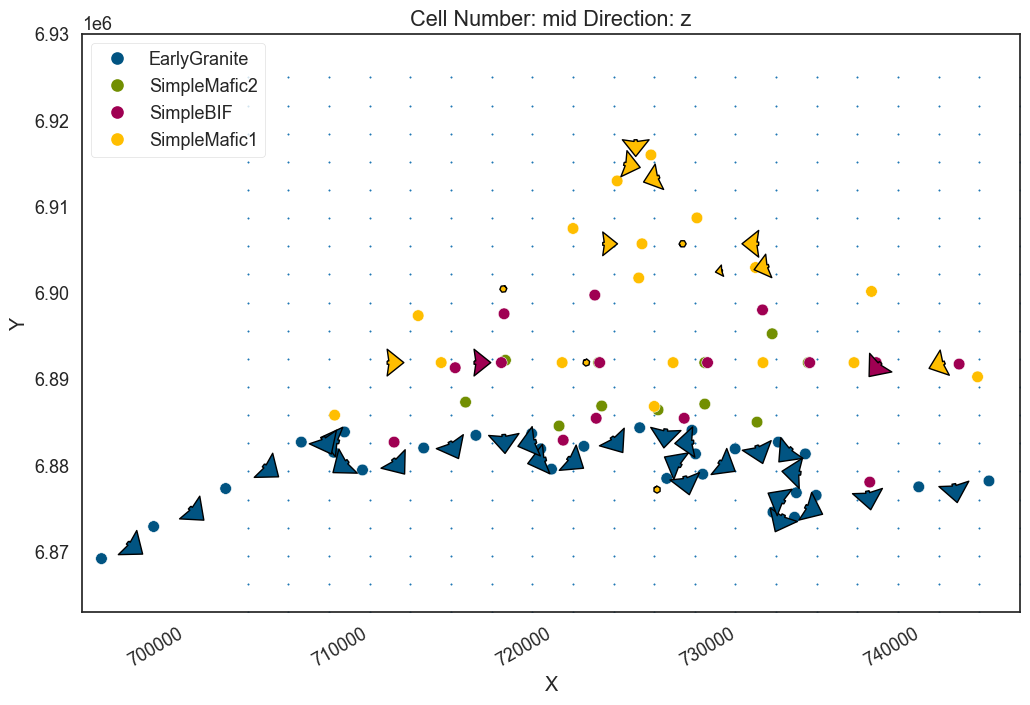

In [7]:
gpv.plot_2d(geo_model, direction='z', show=False)
plt.scatter(xy_ravel[:, 0], xy_ravel[:, 1], s=1)
plt.show()

In [9]:
gp.set_centered_grid(
    grid=geo_model.grid,
    centers=xy_ravel,
    resolution=np.array([10, 10, 15]),
    radius=np.array([5000, 5000, 5000])
)

geo_model.grid.centered_grid.kernel_grid_centers

Active grids: GridTypes.NONE|CENTERED|OCTREE


array([[-5000.        , -5000.        ,  -300.        ],
       [-5000.        , -5000.        ,  -360.        ],
       [-5000.        , -5000.        ,  -383.36972966],
       ...,
       [ 5000.        ,  5000.        , -3407.68480754],
       [ 5000.        ,  5000.        , -4618.11403801],
       [ 5000.        ,  5000.        , -6300.        ]])

In [10]:
gravity_gradient = gp.calculate_gravity_gradient(geo_model.grid.centered_grid)
gravity_gradient

array([-0.00435884, -0.0035374 , -0.00260207, ..., -0.60455378,
       -0.888396  , -0.98280245])

In [11]:
geo_model.geophysics_input = gp.data.GeophysicsInput(
    tz=gravity_gradient,
    densities=np.array([2.61, 2.92, 3.1, 2.92, 2.61]),
)

In [12]:
geo_model.interpolation_options.mesh_extraction = False
sol = gp.compute_model(
    gempy_model=geo_model,
    engine_config=gp.data.GemPyEngineConfig(
        backend=gp.data.AvailableBackends.numpy,
        dtype='float32'
    )
)

grav = sol.gravity

Setting Backend To: AvailableBackends.numpy
Chunking done: 166 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_engine\modules\activator\_soft_segment.py:95: RuntimeWarning: overflow encountered in exp
  return 1.0 / (1.0 + bt.t.exp(x))


Chunking done: 52 chunks
Chunking done: 90 chunks


c:\Users\mrcon\miniconda3\envs\myenv\lib\site-packages\gempy_viewer\API\_plot_2d_API.py:176: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  p.fig.show()


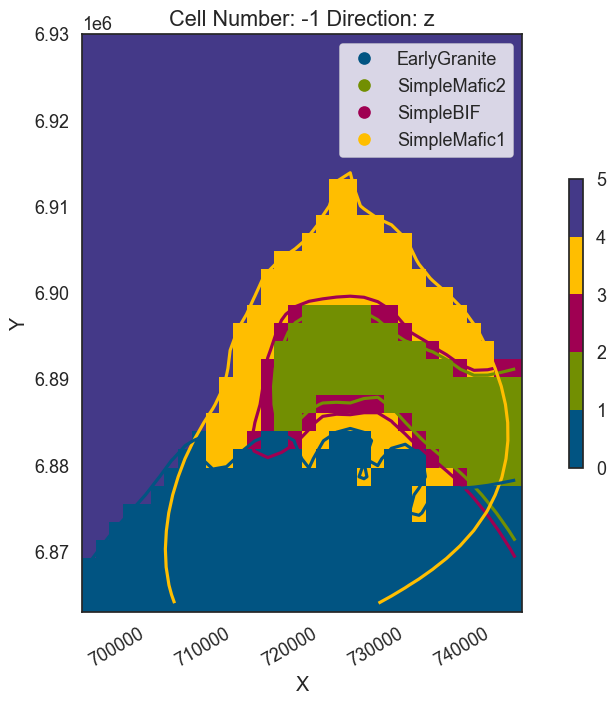

In [13]:
gpv.plot_2d(geo_model, cell_number=[-1], direction=['z'], show_data=False)

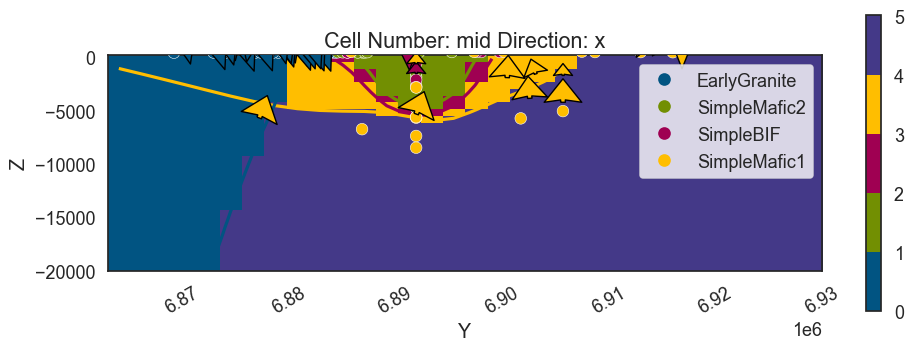

In [14]:
gpv.plot_2d(geo_model, cell_number=['mid'], direction='x')

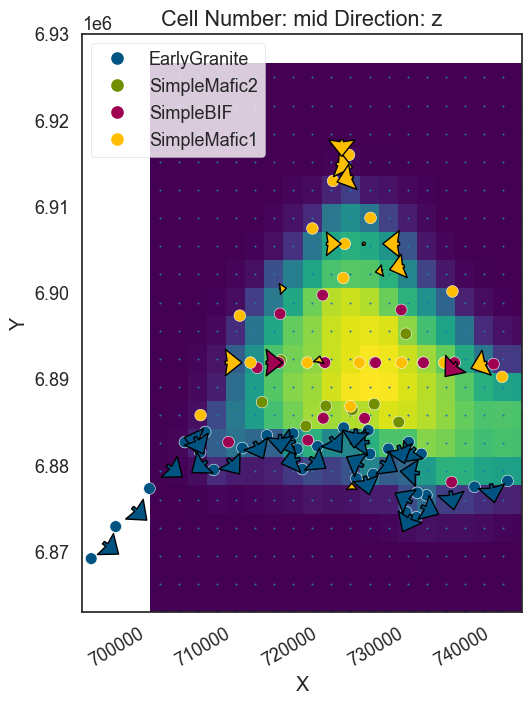

In [15]:
gpv.plot_2d(geo_model, direction=['z'], height=7, show_results=False, show_data=True, show=False)
plt.scatter(xy_ravel[:, 0], xy_ravel[:, 1], s=1)
plt.imshow(sol.gravity.reshape(grav_res, grav_res),
           extent=(xy_ravel[:, 0].min() + (xy_ravel[0, 0] - xy_ravel[1, 0]) / 2,
                   xy_ravel[:, 0].max() - (xy_ravel[0, 0] - xy_ravel[1, 0]) / 2,
                   xy_ravel[:, 1].min() + (xy_ravel[0, 1] - xy_ravel[30, 1]) / 2,
                   xy_ravel[:, 1].max() - (xy_ravel[0, 1] - xy_ravel[30, 1]) / 2),
           cmap='viridis_r', origin='lower')
plt.show()

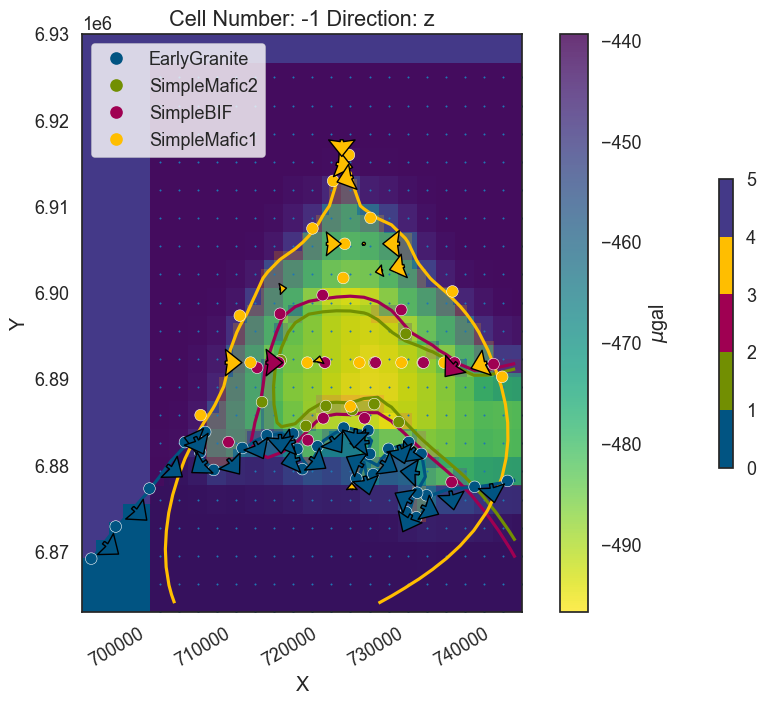

In [16]:
gpv.plot_2d(geo_model, cell_number=[-1], direction=['z'], show=False,
            kwargs_regular_grid={'alpha': .5})

plt.scatter(xy_ravel[:, 0], xy_ravel[:, 1], s=1)
plt.imshow(grav.reshape(grav_res, grav_res),
           extent=(xy_ravel[:, 0].min() + (xy_ravel[0, 0] - xy_ravel[1, 0]) / 2,
                   xy_ravel[:, 0].max() - (xy_ravel[0, 0] - xy_ravel[1, 0]) / 2,
                   xy_ravel[:, 1].min() + (xy_ravel[0, 1] - xy_ravel[30, 1]) / 2,
                   xy_ravel[:, 1].max() - (xy_ravel[0, 1] - xy_ravel[30, 1]) / 2),
           cmap='viridis_r', origin='lower', alpha=.8)
cbar = plt.colorbar()
cbar.set_label(r'$\mu$gal')
plt.show()

# PyGimli

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.viewer import pv
from pygimli.physics.gravimetry import GravityModelling

In [3]:
# Model Extent
min_x = -707522
max_x = -677518
min_y =  4528453
max_y =  4549947
max_z =  505
model_depth = -500
# Convert coordinates to smaller units (divide by 1000 to convert from meters to kilometers)
min_x = min_x / 100
max_x = max_x / 100
min_y = min_y / 100
max_y = max_y / 100
max_z = max_z / 100
model_depth = model_depth / 100
# Set the extent of the model
extent=[min_x, max_x, max_y, min_y, model_depth, max_z]

# Set model resolution
nx = ny = nz = 64  # Define grid resolution
resolution = [nx, ny, nz]

In [4]:
# dx = 64
# x = np.linspace(min_x, max_x, dx)
# y = np.linspace(min_y, max_y, dx)
# z = np.linspace(model_depth, max_z, dx)
# grid = pg.createGrid(x, y, z)
# print(grid)

In [5]:
# dx = 50
# x = np.arange(0., 1001, dx)
# y = np.arange(0., 1001, dx)
# z = np.arange(0., 501, dx)
# grid = pg.createGrid(x, y, z)
# print(grid)

In [6]:
dx = 16
x = np.linspace(0, 1000, dx)
y = np.linspace(0, 1000, dx)
z = np.linspace(0, 100, dx)
grid = pg.createGrid(x, y, z)
print(grid)

Mesh: Nodes: 4096 Cells: 3375 Boundaries: 10800


In [7]:
# Load voxel coordinates and densities from the specified files
voxel_coords = np.load(r"C:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\GeoModel\voxel_coords_below_topo.npy")
densities = np.load(r"C:\Users\mrcon\PycharmProjects\Mineye-Terranigma-1\GeoModel\stratigraphic_lith_block_modified_below_topo.npy")

min_x, max_x = voxel_coords[:, 0].min(), voxel_coords[:, 0].max()
min_y, max_y = voxel_coords[:, 1].min(), voxel_coords[:, 1].max()
min_z, max_z = voxel_coords[:, 2].min(), voxel_coords[:, 2].max()

# Map voxel coordinates to the new coordinate system
# X mapping: from [min_x, max_x] to [0, 1000]
mapped_x = (voxel_coords[:, 0] - min_x) / (max_x - min_x) * 1000

# Y mapping: from [min_y, max_y] to [0, 1000]
mapped_y = (voxel_coords[:, 1] - min_y) / (max_y - min_y) * 1000

# Z mapping: from [model_depth, max_z] to [0, 100]
mapped_z = (voxel_coords[:, 2] - model_depth) / (max_z - model_depth) * 100

# Combine into new coordinate array
voxel_coords = np.column_stack([mapped_x, mapped_y, mapped_z])

print(f"Voxel coordinates shape: {voxel_coords.shape}")
print(f"Densities shape: {densities.shape}")
print(f"Voxel coordinates sample: {voxel_coords[:5]}")
print(f"Densities sample: {densities[:5]}")

Voxel coordinates shape: (210040, 3)
Densities shape: (210040,)
Voxel coordinates sample: [[   0.         1000.          -97.01283547]
 [   0.         1000.          -93.88564761]
 [   0.         1000.          -90.75845974]
 [   0.         1000.          -87.63127188]
 [   0.         1000.          -84.50408401]]
Densities sample: [5 5 5 5 5]


In [8]:
# First, we need to find the indices in our regular grid that correspond to the voxel coordinates
grid_indices = []
for coord in voxel_coords:
    # Find the closest grid indices for each coordinate
    x_idx = np.argmin(np.abs(x - coord[0]))
    y_idx = np.argmin(np.abs(y - coord[1]))
    z_idx = np.argmin(np.abs(z - coord[2]))
    
    # Ensure indices are within bounds
    if 0 <= x_idx < len(x)-1 and 0 <= y_idx < len(y)-1 and 0 <= z_idx < len(z)-1:
        grid_indices.append((z_idx, y_idx, x_idx))

# Reset v to zeros and populate with actual density data
v = np.zeros((len(z)-1, len(y)-1, len(x)-1))
for i, (z_idx, y_idx, x_idx) in enumerate(grid_indices):
    if i < len(densities):
        v[z_idx, y_idx, x_idx] = densities[i]

        
# grid["synth"] = v.ravel()
grid["synth"] = v.ravel()

In [9]:
np.unique(grid["synth"], return_counts=True)

(array([0., 1., 2., 3., 4., 5., 6.]),
 array([ 869,  398,  137,   64,    4,  659, 1244], dtype=int64))

In [10]:
np.size(v)

3375

In [11]:
pl, _ = pg.show(grid, style="wireframe", hold=True)
pv.drawMesh(pl, grid, label="synth", style="surface", cMap="Spectral_r",
            filter={"threshold": dict(value=0.05, scalars="synth")})
pl.camera_position = "yz"
pl.camera.roll = 90
pl.camera.azimuth = 180 - 15
pl.camera.elevation = 10
pl.camera.zoom(1.2)
_ = pl.show()

Widget(value='<iframe src="http://localhost:62516/index.html?ui=P_0x22df2df2590_0&reconnect=auto" class="pyvis…

06/09/25 - 14:41:43 - pyGIMLi - INFO - Cache c:\Users\mrcon\miniconda3\envs\pg\Lib\site-packages\pygimli\physics\gravimetry\kernel.py:SolveGravMagHolstein restored (3.2s x 1): C:\Users\mrcon\AppData\Roaming\pygimli\Cache\17829463668508938929


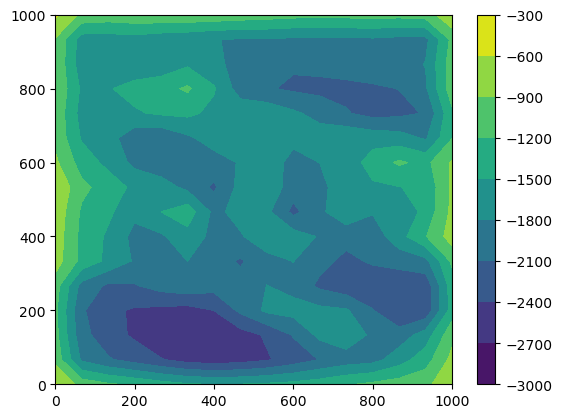

In [12]:
xx, yy = np.meshgrid(x, y)
points = np.column_stack((xx.ravel(), yy.ravel(), -np.ones(np.prod(xx.shape))))
fop = GravityModelling(grid, points)
data = fop.response(grid["synth"])
noise_level = 1
data += np.random.randn(len(data)) * noise_level
plt.contourf(yy, xx, np.reshape(data, xx.shape))
plt.colorbar();

In [13]:
# depth weighting
bz = np.array([b.center().z() for b in grid.boundaries() if not b.outside()])
bn = np.array([b.norm().z() for b in grid.boundaries() if not b.outside()])
z0 = 50
beta = 2.0
wz = (z0 / (bz+z0))**(beta/2)

In [14]:
inv = pg.Inversion(fop=fop, verbose=True)  # , debug=True)
inv.modelTrans = pg.trans.TransCotLU(-2, 2)
# inv.setRegularization(correlationLengths=[500, 500, 100])
inv.setConstraintWeights(wz)
invmodel = inv.run(data, absoluteError=noise_level, lam=1e4,  # zWeight=0.3,
                   startModel=0.1, verbose=True)
grid["inv"] = invmodel

06/09/25 - 14:41:44 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.gravimetry.GravityModelling.GravityModelling object at 0x0000022DF9A6F600>
Data transformation: Identity transform
Model transformation: Cotangens LU transform
min/max (data): -2707/-548
min/max (error): 0.04%/0.18%
min/max (start model): 0.1/0.1
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 2808979.94
--------------------------------------------------------------------------------
inv.iter 1 ... chi² = 993124.00 (dPhi = 64.36%) lam: 10000.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² = 701684.35 (dPhi = 25.88%) lam: 10000.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² = 642391.36 (dPhi = 13.35%) lam: 10000.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² = 637631.33 (dPhi = 0.84%) lam: 10000.0
##################################################

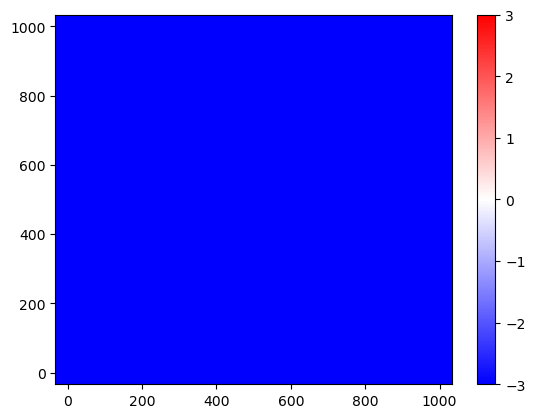

In [15]:
misfit = np.reshape(data-inv.response, xx.shape) / noise_level
plt.pcolor(yy, xx, misfit, cmap="bwr", vmin=-3, vmax=3)
plt.colorbar();

In [16]:
ftr = dict(value=0.5, scalars="synth")
pl, _ = pg.show(grid, label="synth", style="wireframe",
                filter={"threshold": ftr}, hold=True)
ftr = dict(value=0.4, scalars="inv")
pv.drawMesh(pl, grid, label="inv", style="surface", filter={"threshold": ftr},
            cMin=0, cMax=1)
pl.camera_position = "yz"
pl.camera.roll = 90
pl.camera.azimuth = 180
pl.camera.zoom(1.2)
_ = pl.show()

Widget(value='<iframe src="http://localhost:62516/index.html?ui=P_0x22dfd13d890_1&reconnect=auto" class="pyvis…

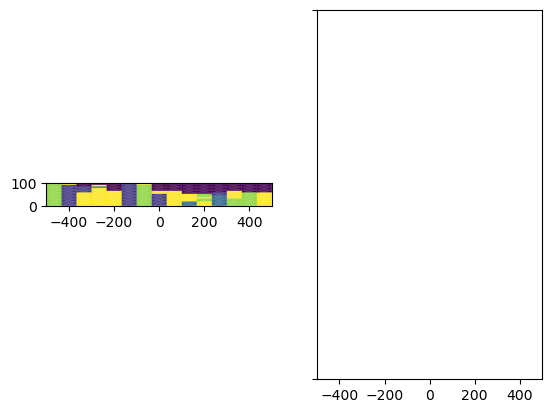

c:\Users\mrcon\miniconda3\envs\pg\Lib\site-packages\pygimli\viewer\mpl\colorbar.py:321: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 3 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)
c:\Users\mrcon\miniconda3\envs\pg\Lib\site-packages\pygimli\viewer\mpl\colorbar.py:321: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 4 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


(100.0, 0.0)

<Figure size 640x480 with 0 Axes>

In [17]:
slice = pg.meshtools.extract2dSlice(grid, origin=[500, 500, 0], normal=[1, 1, 0])
_, ax = plt.subplots(ncols=2, sharex=True, sharey=True)
pg.show(slice, "synth", ax=ax[0])
pg.show(slice, "inv", ax=ax[1])
ax[0].set_ylim(ax[0].get_ylim()[::-1])